### Notebook creado para testear las mejoras o correciones sobre CROP. solo a nivel funcional.

### Preuba de crop 1

2025-11-22 20:12:57.304775: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 20:12:57.308340: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 20:12:57.321004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763853177.338103  300044 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763853177.343006  300044 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763853177.356548  300044 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Usando fashion como dataset


2025-11-22 20:12:59.911804: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-11-22 20:12:59.911820: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-11-22 20:12:59.911825: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: pc-santi
2025-11-22 20:12:59.911829: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: pc-santi
2025-11-22 20:12:59.911884: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 575.64.3
2025-11-22 20:12:59.911901: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:201] kernel reported version is: 575.64.3
2025-

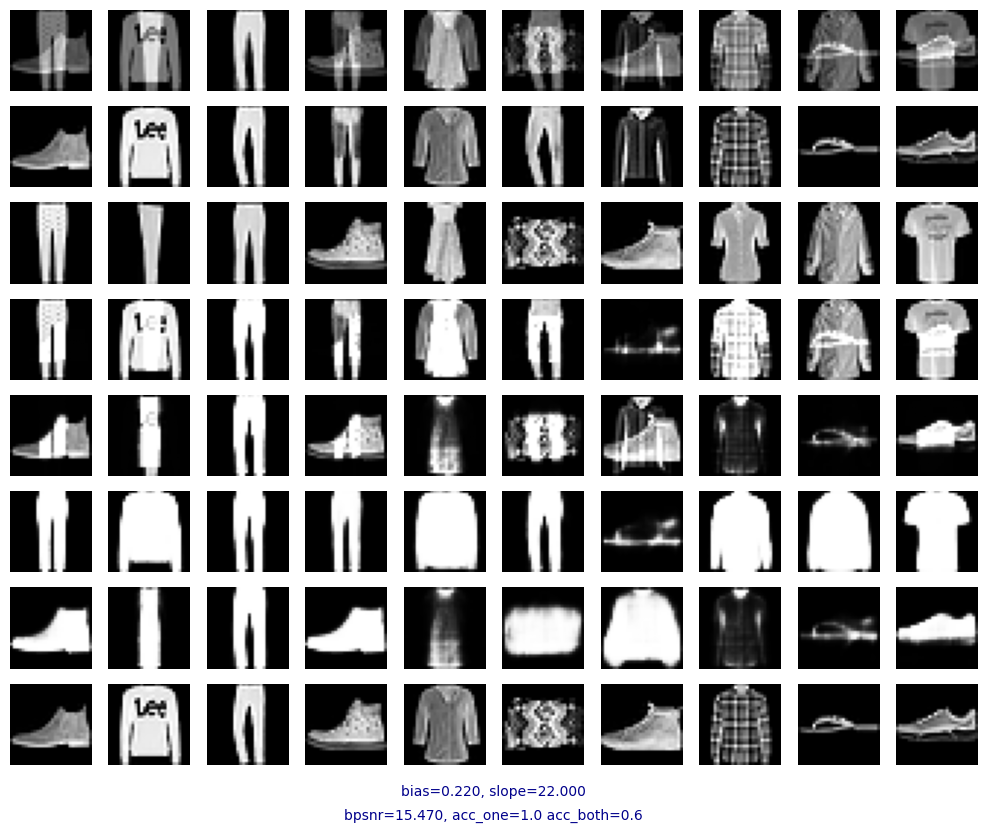

(<tf.Tensor: shape=(), dtype=float32, numpy=15.470026969909668>, <tf.Tensor: shape=(), dtype=float32, numpy=2.730886220932007>)
1.0
0.6


In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop1 import Crop1
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


crop1 = Crop1(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = crop1.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### prueba de crop 2


Usando fashion como dataset


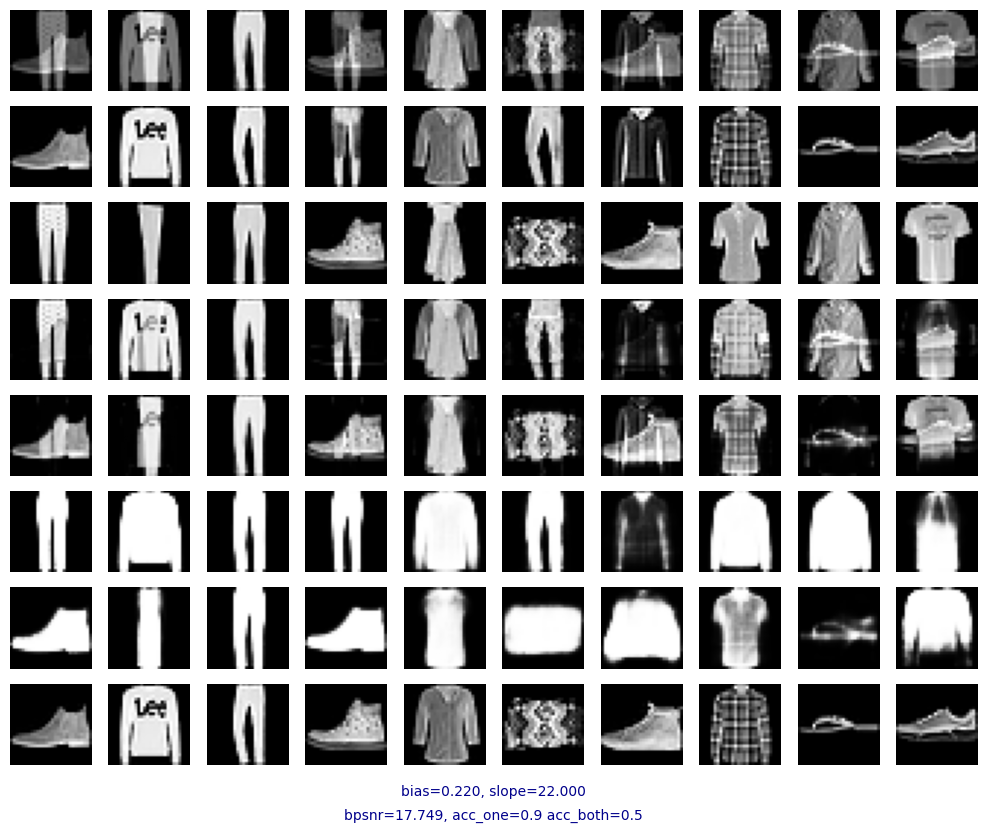

(<tf.Tensor: shape=(), dtype=float32, numpy=17.748716354370117>, <tf.Tensor: shape=(), dtype=float32, numpy=3.6607015132904053>)
0.9
0.5


In [2]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop2 import Crop2
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


crop2 = Crop2(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = crop2.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
    params = {"gamma":0.9}
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### Crop norm


Usando fashion como dataset


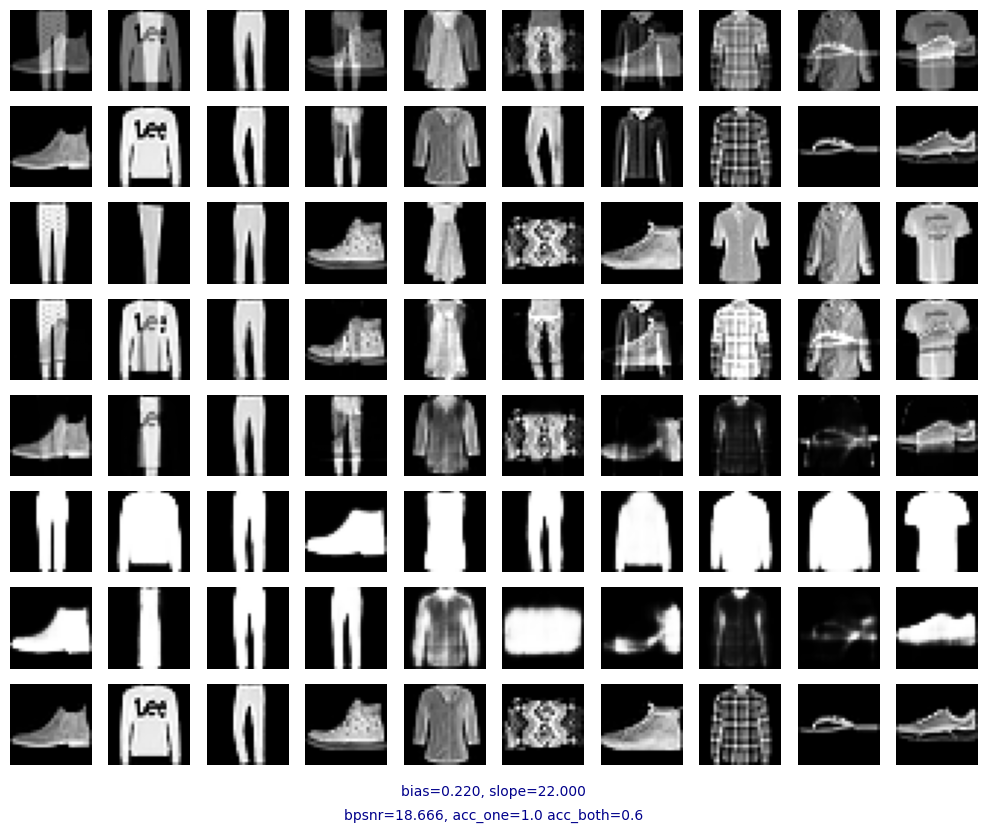

(<tf.Tensor: shape=(), dtype=float32, numpy=18.665786743164062>, <tf.Tensor: shape=(), dtype=float32, numpy=3.6663830280303955>)
1.0
0.6


In [3]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop2_norm import Crop2Norm
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


crop2Norm = Crop2Norm(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = crop2Norm.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
    params = {"gamma":0.9}
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### Crop2 gamma norm

Usando fashion como dataset


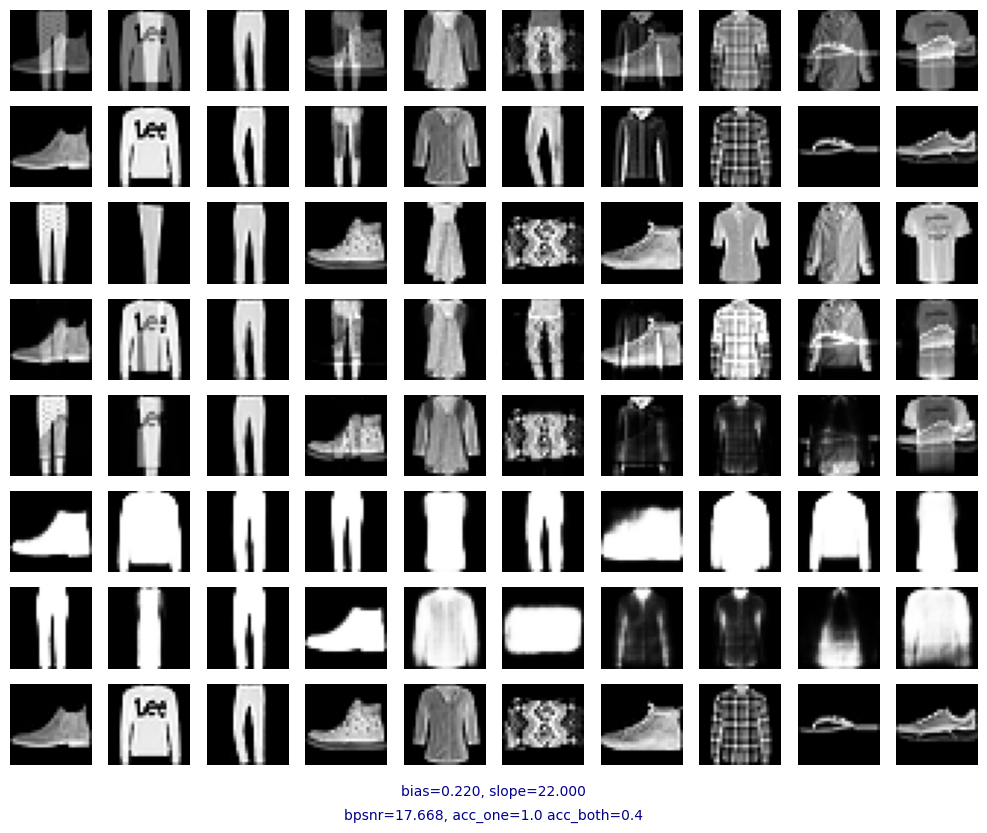

(<tf.Tensor: shape=(), dtype=float32, numpy=17.667552947998047>, <tf.Tensor: shape=(), dtype=float32, numpy=4.12006139755249>)
1.0
0.4


In [4]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load


from project.CROP.models.crop2_gamma_norm import Crop2GammaNorm
dataset = "fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset)

x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]


Crop2GammaNorm = Crop2GammaNorm(
    model,
    predictor=predictor
)


start = 0
end = start + 10


metrics = Crop2GammaNorm.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
    params = {"gamma":0.9}
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

### Curvas de acc



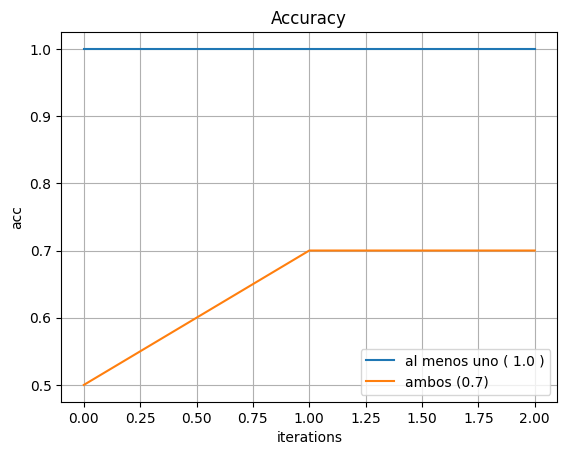

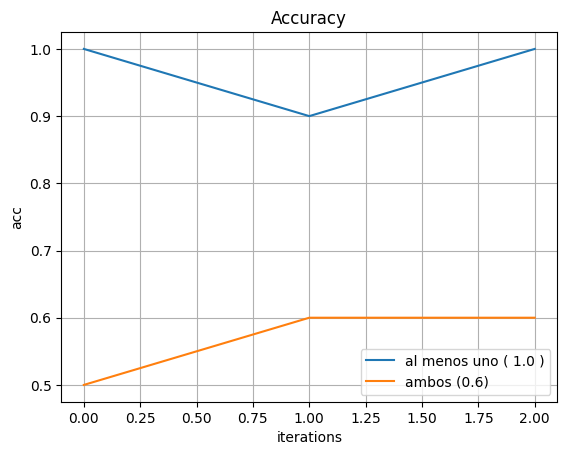

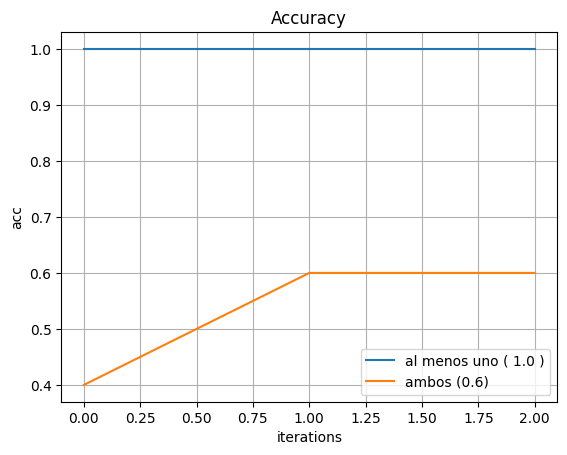

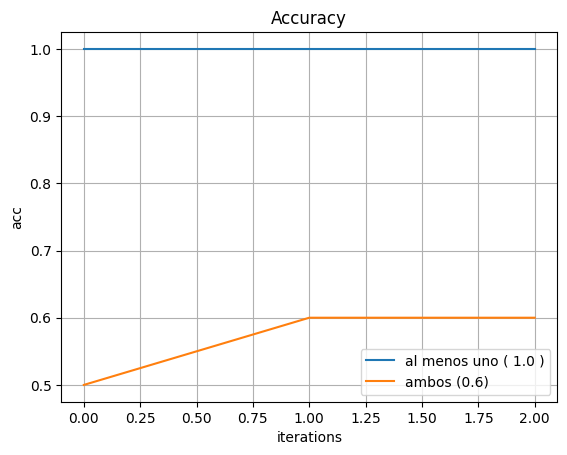

{'acc_at_least_one_plot': [1.0, 1.0, 1.0], 'acc_both_plot': [0.5, 0.6, 0.6]}

In [6]:
from project.CROP.models import crop2_gamma_norm


crop1.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)
crop2.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)
crop2Norm.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)
Crop2GammaNorm.acc_curve( 
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],)

